# Tugas Kelompok Materi 2: Model Regresi Cross-Sectional
## Studi Kasus 3: Simulasi Valuasi Harga Properti dan Estimasi Nilai Jual Rumah
---
**Anggota Kelompok:**
1. [Nama Anda] - Data Architect & Engineer
2. [Nama Partner] - Model Analyst & Strategist

**Dataset:** King County House Data (`kc_house_data.csv`)
**Algoritma:** Support Vector Regression (SVR)

### 1. Setup & Inisialisasi
Menginstal library yang diperlukan dan memuat dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score

# Load Dataset
df = pd.read_csv('data/kc_house_data.csv')
print('Dataset berhasil dimuat. Siap untuk pemrosesan.')

Dataset berhasil dimuat. Siap untuk pemrosesan.


/home/syelha/Documents/pns_2026/kelompok/SalesHouse/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Data Acquisition & EDA (Mahasiswa 1)
Memuat data dan melakukan analisis korelasi awal.

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18

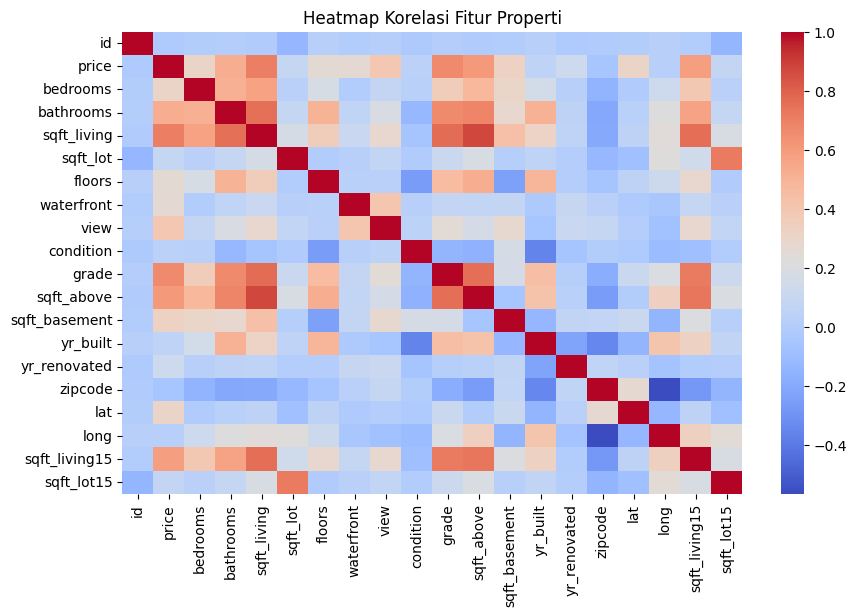

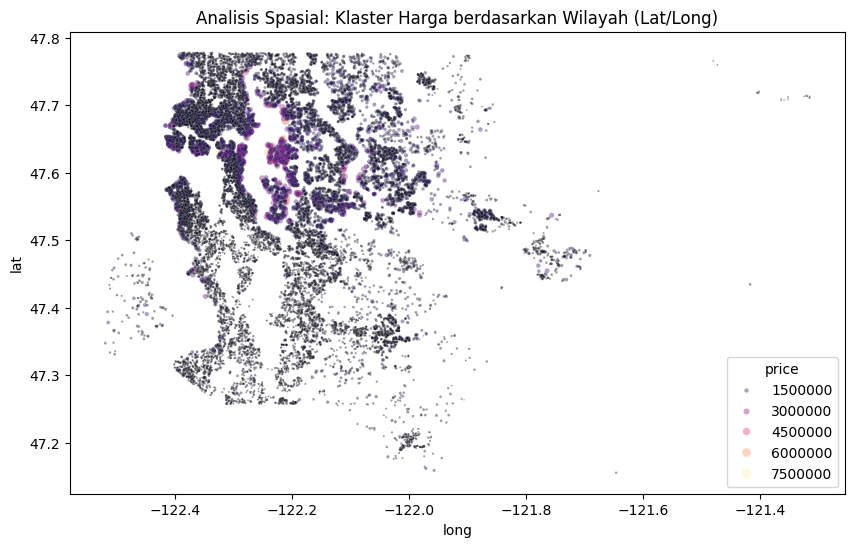

In [2]:
# Memuat dataset

# Identifikasi fitur krusial
print('Informasi Dataset:')
print(df.info())

# 1. Analisis Korelasi dengan Target (Price)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur Properti')
plt.show()

# 2. Analisis Spasial: Sebaran Lokasi vs Harga (Sesuai Aturan Mahasiswa 1)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='long', y='lat', hue='price', palette='magma', alpha=0.4, size='price', sizes=(1, 50))
plt.title('Analisis Spasial: Klaster Harga berdasarkan Wilayah (Lat/Long)')
plt.show()


### 3. Preprocessing & Feature Engineering (Mahasiswa 1)
Tahap validasi, pembersihan data, dan rekayasa fitur.

#### 3.1 Data Cleaning & Outlier Removal
Menangani data yang tidak lazim untuk menjaga kualitas model.

In [3]:
# 1. Data Cleaning: Penanganan Outlier (Sesuai Aturan Mahasiswa 1)
# Menghapus rumah dengan kamar tidur > 10 atau kondisi tidak wajar
df = df[df['bedrooms'] < 10].copy()
print(f'Jumlah data setelah pembersihan outlier: {len(df)} baris')


Jumlah data setelah pembersihan outlier: 21608 baris


#### 3.2 Feature Engineering
Membuat fitur baru House_Age dan Is_Renovated sesuai kebutuhan bisnis.

In [4]:
# 2. Feature Engineering (Sesuai Aturan Mahasiswa 1)
# Ekstraksi Tahun Penjualan dan Hitung Usia Rumah (House_Age)
df['date'] = pd.to_datetime(df['date'])
df['House_Age'] = df['date'].dt.year - df['yr_built']

# Konversi yr_renovated menjadi fitur biner Is_Renovated
df['Is_Renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
print('Fitur House_Age dan Is_Renovated berhasil dibuat.')


Fitur House_Age dan Is_Renovated berhasil dibuat.


#### 3.3 Feature Selection & Data Splitting
Memilih variabel yang relevan dan membagi data menjadi set latih dan set uji.

In [5]:
# 3. Seleksi Fitur & Penanganan Skewness
features = ['bedrooms', 'bathrooms', 'sqft_living', 'view', 'condition', 'grade', 'House_Age', 'Is_Renovated', 'lat', 'long']
X = df[features]
y = df['price']

# Log Transformation pada target
y_log = np.log1p(y)

# 4. Splitting Data (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
print(f'Data berhasil displit. Fitur yang digunakan: {features}')


Data berhasil displit. Fitur yang digunakan: ['bedrooms', 'bathrooms', 'sqft_living', 'view', 'condition', 'grade', 'House_Age', 'Is_Renovated', 'lat', 'long']


#### 3.4 Feature Scaling
Standardisasi fitur numerik menggunakan StandardScaler (Wajib untuk model berbasis kernel).

In [6]:
# 5. Feature Scaling (WAJIB untuk SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Scaling selesai. Data siap untuk pemodelan.')


Scaling selesai. Data siap untuk pemodelan.


### 4. Regression Modeling (Mahasiswa 2)
Implementasi Support Vector Regression dengan Kernel RBF.

In [7]:
# Inisialisasi SVR dengan Parameter C cerdas
svr_model = SVR(kernel='rbf', C=10.0, epsilon=0.1, gamma='scale')

print("Melatih model SVR (RBF Kernel)... Mohon tunggu.")
svr_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred_log = svr_model.predict(X_test_scaled)

# Kembalikan ke nilai asli (Exp)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

Melatih model SVR (RBF Kernel)... Mohon tunggu.


### 5. Model Assessment (Mahasiswa 2)
Evaluasi presisi menggunakan MAE, RMSE, dan R-Squared.

--- HASIL EVALUASI MODEL SVR ---
MAE  : $89,595.91
RMSE : $191,140.61
R2 Score: 0.7527


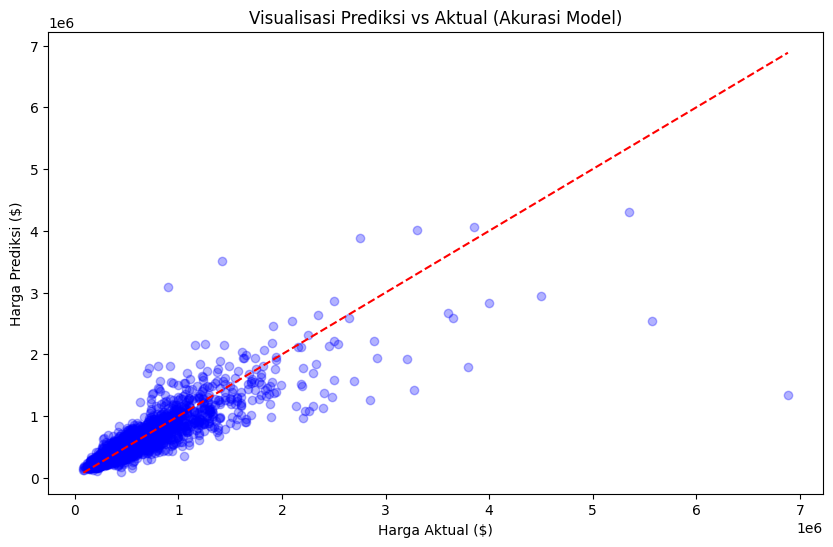

In [8]:
mae = mean_absolute_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2 = r2_score(y_test_orig, y_pred_orig)

print("--- HASIL EVALUASI MODEL SVR ---")
print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R2 Score: {r2:.4f}")

# Visualisasi Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.3, color='blue')
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], '--r')
plt.xlabel('Harga Aktual ($)')
plt.ylabel('Harga Prediksi ($)')
plt.title('Visualisasi Prediksi vs Aktual (Akurasi Model)')
plt.show()

### 6. Explainable AI: Interpretasi Model dengan SHAP (Mahasiswa 2)
Membongkar variabel fisik mana yang paling "mahal" bagi sebuah rumah.

Menghitung SHAP values (Optimized)... Mohon tunggu.


100%|██████████| 30/30 [00:14<00:00,  2.01it/s]


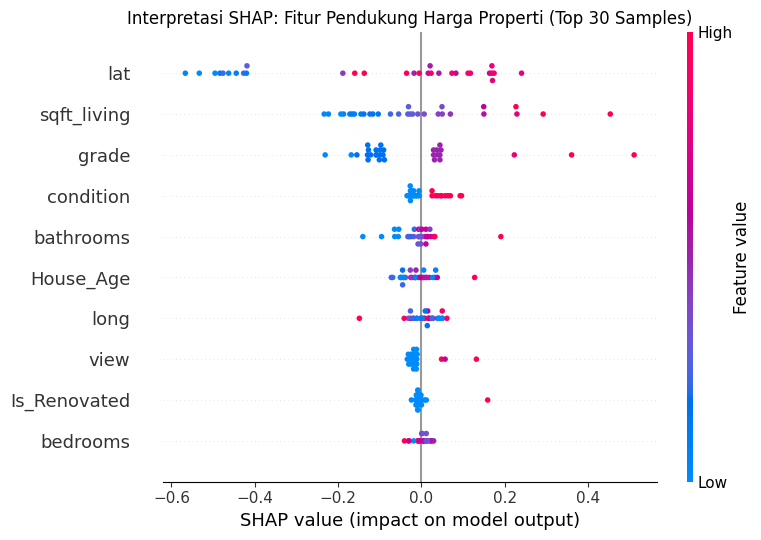

In [9]:
# Optimasi SHAP: Menggunakan kmeans untuk background dan mengurangi jumlah sampel
# Hal ini akan mempercepat proses interpretasi secara signifikan
print("Menghitung SHAP values (Optimized)... Mohon tunggu.")
background_summary = shap.kmeans(X_train_scaled, 10) # 10 cluster jauh lebih cepat dari 100 random samples
explainer = shap.KernelExplainer(svr_model.predict, background_summary)

# Hitung untuk 30 sampel saja (sudah cukup untuk melihat tren fitur)
shap_values = explainer.shap_values(X_test_scaled[:30], nsamples=100) 

plt.figure(figsize=(10, 6))
plt.title("Interpretasi SHAP: Fitur Pendukung Harga Properti (Top 30 Samples)")
shap.summary_plot(shap_values, X_test.iloc[:30], feature_names=features)


### 7. Simulasi Valuasi: Skenario "What-If" (Mahasiswa 2)
Simulasi dampak renovasi properti terhadap kenaikan harga jual.

In [10]:
def valuation_simulator(house_index, quality_upgrade=2, renovate=True):
    # Ambil satu sampel rumah dari test set
    house_original = X_test.iloc[house_index].copy()
    original_price_log = y_test.iloc[house_index]
    original_price = np.expm1(original_price_log)
    
    # Skenario 'What-If': Renovasi Total (Sesuai Aturan Mahasiswa 2)
    house_renovated = house_original.copy()
    house_renovated['grade'] = min(house_renovated['grade'] + quality_upgrade, 13)
    if renovate:
        house_renovated['Is_Renovated'] = 1
        house_renovated['condition'] = min(house_renovated['condition'] + 1, 5)
    
    # Prediksi
    # Membuat DataFrame untuk memastikan nama fitur sesuai saat transform
    input_df = pd.DataFrame([house_original, house_renovated], columns=features)
    input_scaled = scaler.transform(input_df)
    predictions_log = svr_model.predict(input_scaled)
    pred_prices = np.expm1(predictions_log)
    
    print(f'--- SIMULASI VALUASI RUMAH INDEKS {house_index} ---')
    print(f'Harga Aktual (Pasar)      : ${original_price:,.2f}')
    print(f'Estimasi Setelah Renovasi : ${pred_prices[1]:,.2f}')
    print(f'Potensi Kenaikan Harga    : ${pred_prices[1] - pred_prices[0]:,.2f}')
    print(f'Peningkatan Grade         : +{quality_upgrade} tingkat')
    print(f'Status Renovasi           : {'Ya' if renovate else 'Tidak'}')
    print('-' * 45)

# Uji Simulasi untuk 5 Sampel Acak (Sesuai Aturan PDF)
print('Menjalankan Simulasi What-If untuk 5 Properti...\n')
for i in range(5):
    valuation_simulator(house_index=i*10, quality_upgrade=2, renovate=True)


Menjalankan Simulasi What-If untuk 5 Properti...

--- SIMULASI VALUASI RUMAH INDEKS 0 ---
Harga Aktual (Pasar)      : $685,000.00
Estimasi Setelah Renovasi : $863,985.19
Potensi Kenaikan Harga    : $77,501.43
Peningkatan Grade         : +2 tingkat
Status Renovasi           : Ya
---------------------------------------------
--- SIMULASI VALUASI RUMAH INDEKS 10 ---
Harga Aktual (Pasar)      : $647,500.00
Estimasi Setelah Renovasi : $505,711.14
Potensi Kenaikan Harga    : $119,965.73
Peningkatan Grade         : +2 tingkat
Status Renovasi           : Ya
---------------------------------------------
--- SIMULASI VALUASI RUMAH INDEKS 20 ---
Harga Aktual (Pasar)      : $1,215,000.00
Estimasi Setelah Renovasi : $1,876,191.82
Potensi Kenaikan Harga    : $1,021,613.17
Peningkatan Grade         : +2 tingkat
Status Renovasi           : Ya
---------------------------------------------
--- SIMULASI VALUASI RUMAH INDEKS 30 ---
Harga Aktual (Pasar)      : $575,000.00
Estimasi Setelah Renovasi : $764,5